In [ ]:
import os 
import glob
import warnings
import random
import numpy as np 
from tqdm import tqdm
from utils.plots import *
from rl.agent import TDLearning,TDLearning_V
from utils.path import PathConfig,FigureWithData
import importlib


warnings.filterwarnings("ignore")
seed_value =1234
np.random.seed(seed_value)
random.seed(seed_value)

fig_dir = os.path.join('figures', 'figure_S5')
data_fig_dir = os.path.join('data', 'source_data', 'figure_S5')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)


## Reinforcement learning simulations 


Types of simulations  (`simulation_type`) are {`eta_sampling_`, `eta_nosampling_nodistr_`, `eta_nosampling_nodistr_`}


`eta_sampling_`: TD learning with DRL performing sampling for the computation of next step value predictors. 
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{z}(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{z}(s_{t+1})$ is a sample from the distribution defined by the set of $\hat{V}_i(s_{t+1})$
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$  

`eta_nosampling_nodistr_`: TD learning not DRL using the mean across  $\tau s $  
$$
\delta_{t} = r_t + \gamma \cdot V(s_{t+1}) - V(s_t)\\
\hat{\delta}_{t} ~~ = ~~~\hat{\tau} \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} >0 \\
\hat{\delta}_{t}  =(1-\hat{\tau}) \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} \leq 0
$$

- Where $ \hat{\tau}$ is the mean of the $\tau_i$ across the population of each group
- Update of value:
$$
P(s_t) \leftarrow P(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P(s_t) ~~~... ~~~\text{if} ~ \delta_{t} >0\\
N(s_t) \leftarrow N(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N(s_t) ~~~... ~~~\text{if} ~ \delta_{t} \leq 0 \\
\hat{V}(s_t) = P(s_t) - N(s_t)
$$  


`eta_nosampling_`: TD learning with DRL without performing sampling for the computation of next step value predictors
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{V}_i(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{V}_i(s_{t+1})$  is the value predictor in the next time step
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$ 

**Note**: To plot and use the present notebook the user needs to download the data inside `analysis` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [2]:
paths = PathConfig()
alpha_pos_da = np.linspace(.1,.9,20)[None,:]
alpha_neg_da = 1-alpha_pos_da
taus_da= (alpha_pos_da)/(alpha_pos_da+alpha_neg_da)
alpha_pos_rec = np.linspace(.1,.9,10)[:,None]
alpha_neg_rec = 1- alpha_pos_rec
taus_rec= (alpha_pos_rec)/(alpha_pos_rec+alpha_neg_rec)
taus_prod = (alpha_pos_rec@alpha_pos_da)/((alpha_pos_rec@alpha_pos_da)+(alpha_neg_rec@alpha_neg_da))


In [3]:
# Mechanism 2 in risk sensitive TD learning
simulation_type = 'eta_nosampling_' 
epsilon_ = 0.01
taus_da =  np.linspace(0.05,0.95,10)
tau_rec =0.5
save_dics_mech2 = dict()
for tau_da in tqdm(taus_da):
    taus_ = np.array([tau_da])
    etas =  np.array([tau_rec])
    n_iterations = len(etas) 
    for ie in np.arange(n_iterations):
        s = dict()
        s['agent'] = dict()
        s['task'] = dict()
        if simulation_type == 'eta_nosampling_' :
            s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
            s['agent']['do_sampling'] = False
        elif simulation_type == 'eta_nosampling_nodistr_': 
            s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
            s['agent']['do_sampling'] = False
        elif simulation_type == 'eta_sampling_': 
            s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
            s['agent']['do_sampling'] = True
        
        s['agent']['eta'] = etas[ie]
        s['agent']['str_agent'] = ['Eta_' + str(etas[ie])]#,'neutral','optimistic']
        s['agent']['epsilon'] = epsilon_
        s['agent']['base_alpha'] = 1
        s['agent']['gamma'] =1
        
        s['agent']['d1_d2'] = True
        s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ,[.8, .2]]
        s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ,[-1, 0]]
        s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
        s['task']['cs_id'] = [[0,0],[1,1],[2,2],[3,3]]
        s['task']['str_cs'] = [ '10%','50%','90%','80%Puff']
        s['task']['str_task'] = 'drl_6odor'
        s['task']['n_trials'] = 10000
        s['task']['cue_onset'] = 1
        s['task']['cue_dur'] = 1
        s['task']['rew_onset'] = 3
        s['task']['iti_dur'] = 1
        s['task']['n_iterations'] = 1
        s['task']['type'] = 'cue_reward'
        s['task']['seed'] = seed_value

        agent = TDLearning(s)
        agent.initialize_results()
        agent.run_task()
        agent.reformat_results()
        save_dic = dict()
        results = dict()
        save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                     'distribution_trials_full2', 'distribution_g_trials_full2', 'distribution_ng_trials_full2',  'deltas_trials_full2', 
                    'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
        for ivar in save_vars:
            temp = agent.results[ivar]
            if len(temp.shape)==4:
                id_end = np.argwhere(np.nansum(temp,axis=(0,1,2))==0).flatten()[0]
                temp = temp[:,:,:,:id_end]
            results[ivar] = temp
        save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
        new_dict = vars(agent)
        for ivar in save_vars:
            results[ivar] = new_dict[ivar]
        agent_dict = dict()
        save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                    'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                    'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                    'i_step_per_cs']
        for ivar in save_vars:
            agent_dict[ivar] = new_dict[ivar]
        save_dic['results'] = results
        save_dic['agent'] = agent_dict
        save_dic['task'] = vars(agent.task)
        save_dic['eta'] = etas
    save_dics_mech2[str(tau_da)]=save_dic

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:12<00:00,  1.27s/it]


Saved figure to figures/figure_S5/figure_S5ab_risk_sensitive_mech2.pdf
Saved data and stats to data/figure_data/figure_S5/figure_S5ab_risk_sensitive_mech2.txt


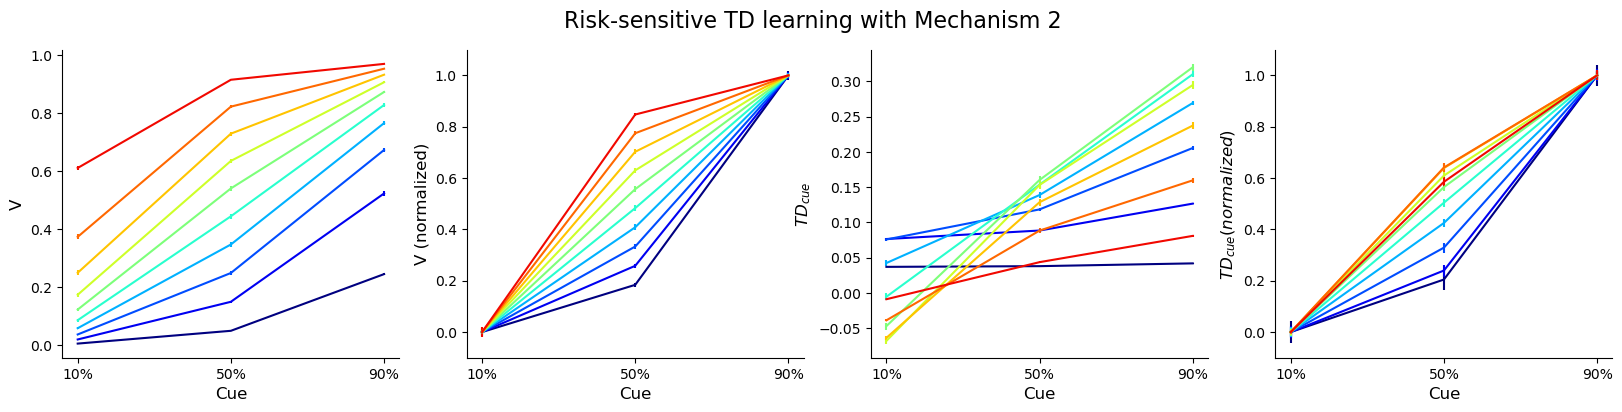

In [6]:
# Plot Supp Fig 5 a-b
idict = save_dics_mech2
taus_i =  taus_da
ntr_count=-500
id_cue_trtype = [0,1,2]

fig,ax=plt.subplots(1,4,figsize=(20,4))
fig_data_S5ab = FigureWithData(fig)

for (it,tau_i) in enumerate(taus_i):
    res = idict[str(tau_i)]['results']
    ag = idict[str(tau_i)]['agent']
    gamma_ = ag['gamma']

    td_trial = res['deltas_trials_full2'][0,id_cue_trtype,1,ntr_count:] #(3x trials)
    td_trial_mu,td_trial_sem = np.nanmean(td_trial,axis=-1), np.nanstd(td_trial,axis=-1)/np.sqrt(np.sum(~np.isnan(td_trial),axis=-1))
    td_trial_n = (td_trial-td_trial_mu[0])/(td_trial_mu[-1]-td_trial_mu[0])
    td_trial_n_mu,td_trial_n_sem = np.nanmean(td_trial_n,axis=-1), np.nanstd(td_trial_n,axis=-1)/np.sqrt(np.sum(~np.isnan(td_trial_n),axis=-1))

    v_trial = res['distribution_trials_full2'][0,id_cue_trtype,3,ntr_count:] #(3x trials)
    v_trial_mu,v_trial_sem = np.nanmean(v_trial,axis=-1), np.nanstd(v_trial,axis=-1)/np.sqrt(np.sum(~np.isnan(v_trial),axis=-1))
    v_trial_n = (v_trial-v_trial_mu[0])/(v_trial_mu[-1]-v_trial_mu[0])
    v_trial_n_mu,v_trial_n_sem = np.nanmean(v_trial_n,axis=-1), np.nanstd(v_trial_n,axis=-1)/np.sqrt(np.sum(~np.isnan(v_trial_n),axis=-1))

    ax[0].errorbar(np.arange(len(v_trial)),v_trial_mu,v_trial_sem,color=cm.jet(it/len(taus_i)))
    ax[1].errorbar(np.arange(len(v_trial)),v_trial_n_mu,v_trial_n_sem,color=cm.jet(it/len(taus_i)))
    ax[2].errorbar(np.arange(len(td_trial)),td_trial_mu,td_trial_sem,color=cm.jet(it/len(taus_i)))
    ax[3].errorbar(np.arange(len(td_trial)),td_trial_n_mu,td_trial_n_sem,color=cm.jet(it/len(taus_i)))

    # Save all 4 panels
    fig_data_S5ab.add_data(
        f"V_tau_{tau_i}",
        np.column_stack((np.arange(len(v_trial_mu)), v_trial_mu, v_trial_sem)),
        ['Cue_Index', 'V_mean', 'V_SEM']
    )
    fig_data_S5ab.add_data(
        f"V_norm_tau_{tau_i}",
        np.column_stack((np.arange(len(v_trial_n_mu)), v_trial_n_mu, v_trial_n_sem)),
        ['Cue_Index', 'V_norm_mean', 'V_norm_SEM']
    )
    fig_data_S5ab.add_data(
        f"TD_tau_{tau_i}",
        np.column_stack((np.arange(len(td_trial_mu)), td_trial_mu, td_trial_sem)),
        ['Cue_Index', 'TD_mean', 'TD_SEM']
    )
    fig_data_S5ab.add_data(
        f"TD_norm_tau_{tau_i}",
        np.column_stack((np.arange(len(td_trial_n_mu)), td_trial_n_mu, td_trial_n_sem)),
        ['Cue_Index', 'TD_norm_mean', 'TD_norm_SEM']
    )

plot_config(ax[0],'Cue',r'V',12,False)
plot_config(ax[1],'Cue',r'V (normalized)' ,12,False)
plot_config(ax[2],'Cue',r'$TD_{cue}$',12,False)
plot_config(ax[3],'Cue',r'$TD_{cue} (normalized)$ ' ,12,False)
[ia.set_xticks(np.arange(len(v_trial))) for ia in ax]
[ia.set_xticklabels(['10%','50%','90%']) for ia in ax]
[ia.set_ylim([-.1,1.1]) for ia in [ax[1],ax[3]]]
plt.suptitle('Risk-sensitive TD learning with Mechanism 2',fontsize=16)


# --- Save everything
fig_data_S5ab.save(
    base_filename='figure_S5ab_risk_sensitive_mech2',
    folder_data= data_fig_dir,
    folder_figures=fig_dir
)

In [7]:
# Mechanism 1 in risk sensitive TD learning
simulation_type = 'eta_nosampling_' 
epsilon_ = 0.01    
taus_rec =  np.linspace(0.05,0.95,10)
tau_da =0.5
save_dics_mech1 = dict()
for tau_rec in tqdm(taus_rec):
    taus_ = np.array([tau_da])
    etas =  np.array([tau_rec])
    n_iterations = len(etas) 
    for ie in np.arange(n_iterations):
        s = dict()
        s['agent'] = dict()
        s['task'] = dict()
        if simulation_type == 'eta_nosampling_' :
            s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
            s['agent']['do_sampling'] = False
        elif simulation_type == 'eta_nosampling_nodistr_': 
            s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
            s['agent']['do_sampling'] = False
        elif simulation_type == 'eta_sampling_': 
            s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
            s['agent']['do_sampling'] = True
        
        s['agent']['eta'] = etas[ie]
        s['agent']['str_agent'] = ['Eta_' + str(etas[ie])]#,'neutral','optimistic']
        s['agent']['epsilon'] = epsilon_
        s['agent']['base_alpha'] = 1
        s['agent']['gamma'] = 1
        
        s['agent']['d1_d2'] = True
        s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ,[.8, .2]]
        s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ,[-1, 0]]
        s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
        s['task']['cs_id'] = [[0,0],[1,1],[2,2],[3,3]]
        s['task']['str_cs'] = [ '10%','50%','90%','80%Puff']
        s['task']['str_task'] = 'drl_6odor'
        s['task']['n_trials'] = 10000
        s['task']['cue_onset'] = 1
        s['task']['cue_dur'] = 1
        s['task']['rew_onset'] = 3
        s['task']['iti_dur'] = 1
        s['task']['n_iterations'] = 1
        s['task']['type'] = 'cue_reward'
        s['task']['seed'] = seed_value

        agent = TDLearning(s)
        agent.initialize_results()
        agent.run_task()
        agent.reformat_results()
        save_dic = dict()
        results = dict()
        save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                     'distribution_trials_full2', 'distribution_g_trials_full2', 'distribution_ng_trials_full2',  'deltas_trials_full2', 
                    'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
        for ivar in save_vars:
            temp = agent.results[ivar]
            if len(temp.shape)==4:
                id_end = np.argwhere(np.nansum(temp,axis=(0,1,2))==0).flatten()[0]
                temp = temp[:,:,:,:id_end]
            results[ivar] = temp
        save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
        new_dict = vars(agent)
        for ivar in save_vars:
            results[ivar] = new_dict[ivar]
        agent_dict = dict()
        save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                    'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                    'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                    'i_step_per_cs']
        for ivar in save_vars:
            agent_dict[ivar] = new_dict[ivar]
        save_dic['results'] = results
        save_dic['agent'] = agent_dict
        save_dic['task'] = vars(agent.task)
        save_dic['eta'] = etas
    save_dics_mech1[str(tau_rec)]=save_dic

100%|██████████| 10/10 [00:12<00:00,  1.29s/it]


Saved figure to figures/figure_S5/figure_S5ef_risk_sensitive_mech1.pdf
Saved data and stats to data/figure_data/figure_S5/figure_S5ef_risk_sensitive_mech1.txt


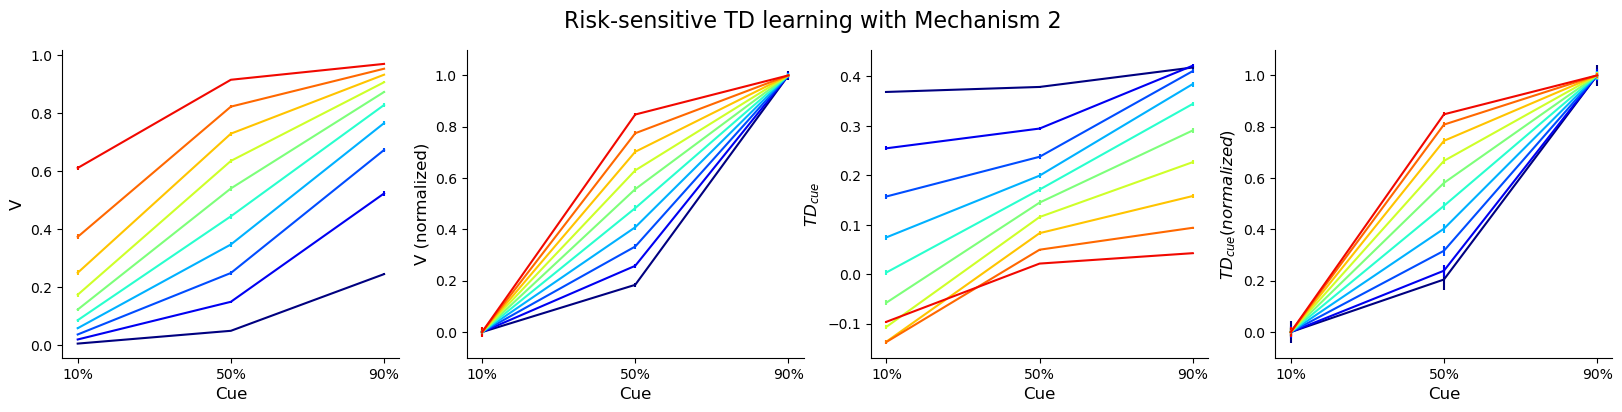

In [11]:
# Plot Supp Fig 5 e-f
idict = save_dics_mech1
taus_i =  taus_rec
ntr_count=-500
id_cue_trtype = [0,1,2]

fig,ax=plt.subplots(1,4,figsize=(20,4))
fig_data_S5ef = FigureWithData(fig)

for (it,tau_i) in enumerate(taus_i):
    res = idict[str(tau_i)]['results']
    ag = idict[str(tau_i)]['agent']
    gamma_ = ag['gamma']

    td_trial = res['deltas_trials_full2'][0,id_cue_trtype,1,ntr_count:] #(3x trials)
    td_trial_mu,td_trial_sem = np.nanmean(td_trial,axis=-1), np.nanstd(td_trial,axis=-1)/np.sqrt(np.sum(~np.isnan(td_trial),axis=-1))
    td_trial_n = (td_trial-td_trial_mu[0])/(td_trial_mu[-1]-td_trial_mu[0])
    td_trial_n_mu,td_trial_n_sem = np.nanmean(td_trial_n,axis=-1), np.nanstd(td_trial_n,axis=-1)/np.sqrt(np.sum(~np.isnan(td_trial_n),axis=-1))

    v_trial = res['distribution_trials_full2'][0,id_cue_trtype,3,ntr_count:] #(3x trials)
    v_trial_mu,v_trial_sem = np.nanmean(v_trial,axis=-1), np.nanstd(v_trial,axis=-1)/np.sqrt(np.sum(~np.isnan(v_trial),axis=-1))
    v_trial_n = (v_trial-v_trial_mu[0])/(v_trial_mu[-1]-v_trial_mu[0])
    v_trial_n_mu,v_trial_n_sem = np.nanmean(v_trial_n,axis=-1), np.nanstd(v_trial_n,axis=-1)/np.sqrt(np.sum(~np.isnan(v_trial_n),axis=-1))

    ax[0].errorbar(np.arange(len(v_trial)),v_trial_mu,v_trial_sem,color=cm.jet(it/len(taus_i)))
    ax[1].errorbar(np.arange(len(v_trial)),v_trial_n_mu,v_trial_n_sem,color=cm.jet(it/len(taus_i)))
    ax[2].errorbar(np.arange(len(td_trial)),td_trial_mu,td_trial_sem,color=cm.jet(it/len(taus_i)))
    ax[3].errorbar(np.arange(len(td_trial)),td_trial_n_mu,td_trial_n_sem,color=cm.jet(it/len(taus_i)))


    fig_data_S5ef.add_data(
        f"V_tau_{tau_i}",
        np.column_stack((np.arange(len(v_trial_mu)), v_trial_mu, v_trial_sem)),
        ['Cue_Index', 'V_mean', 'V_SEM']
    )
    fig_data_S5ef.add_data(
        f"V_norm_tau_{tau_i}",
        np.column_stack((np.arange(len(v_trial_n_mu)), v_trial_n_mu, v_trial_n_sem)),
        ['Cue_Index', 'V_norm_mean', 'V_norm_SEM']
    )
    fig_data_S5ef.add_data(
        f"TD_tau_{tau_i}",
        np.column_stack((np.arange(len(td_trial_mu)), td_trial_mu, td_trial_sem)),
        ['Cue_Index', 'TD_mean', 'TD_SEM']
    )
    fig_data_S5ef.add_data(
        f"TD_norm_tau_{tau_i}",
        np.column_stack((np.arange(len(td_trial_n_mu)), td_trial_n_mu, td_trial_n_sem)),
        ['Cue_Index', 'TD_norm_mean', 'TD_norm_SEM']
    )
    

plot_config(ax[0],'Cue',r'V',12,False)
plot_config(ax[1],'Cue',r'V (normalized)' ,12,False)
plot_config(ax[2],'Cue',r'$TD_{cue}$',12,False)
plot_config(ax[3],'Cue',r'$TD_{cue} (normalized)$ ' ,12,False)
[ia.set_xticks(np.arange(len(v_trial))) for ia in ax]
[ia.set_xticklabels(['10%','50%','90%']) for ia in ax]
[ia.set_ylim([-.1,1.1]) for ia in [ax[1],ax[3]]]
plt.suptitle('Risk-sensitive TD learning with Mechanism 2',fontsize=16)


# --- Save everything
fig_data_S5ef.save(
    base_filename='figure_S5ef_risk_sensitive_mech1',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)

In [9]:
# Mechanism 1 in distributional TD learning
simulation_type = 'eta_sampling_' 
epsilon_ = 0.001    
apos_da = np.linspace(.1,.9,15)[None,:]
aneg_da = 1-apos_da
asym_scaling = np.linspace(0.1,1,10)[:,None]
taus_da = ((apos_da*asym_scaling[None,:])/((apos_da*asym_scaling[None,:])+(aneg_da*(1-asym_scaling[None,:])))).squeeze()

tau_rec =0.5
save_dics_drl_mech2 = dict()
for ii in tqdm(range(len(asym_scaling))):
    taus_ = taus_da[ii,:]
    etas =  np.array([tau_rec])
    n_iterations = len(etas) 
    for ie in np.arange(n_iterations):
        s = dict()
        s['agent'] = dict()
        s['task'] = dict()
        if simulation_type == 'eta_nosampling_' :
            s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
            s['agent']['do_sampling'] = False
        elif simulation_type == 'eta_nosampling_nodistr_': 
            s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
            s['agent']['do_sampling'] = False
        elif simulation_type == 'eta_sampling_': 
            s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
            s['agent']['do_sampling'] = True
        
        s['agent']['eta'] = etas[ie]
        s['agent']['str_agent'] = ['Eta_' + str(etas[ie])]#,'neutral','optimistic']
        s['agent']['epsilon'] = epsilon_
        s['agent']['base_alpha'] = 1
        s['agent']['gamma'] = .98
        
        s['agent']['d1_d2'] = True
        s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ,[.8, .2]]
        s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ,[-1, 0]]
        s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
        s['task']['cs_id'] = [[0,0],[1,1],[2,2],[3,3]]
        s['task']['str_cs'] = [ '10%','50%','90%','80%Puff']
        s['task']['str_task'] = 'drl_6odor'
        s['task']['n_trials'] = 10000
        s['task']['cue_onset'] = 1
        s['task']['cue_dur'] = 1
        s['task']['rew_onset'] = 3
        s['task']['iti_dur'] = 1
        s['task']['n_iterations'] = 1
        s['task']['type'] = 'cue_reward'
        s['task']['seed'] = seed_value

        agent = TDLearning(s)
        agent.initialize_results()
        agent.run_task()
        agent.reformat_results()
        save_dic = dict()
        results = dict()
        save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                     'distribution_trials_full2', 'distribution_g_trials_full2', 'distribution_ng_trials_full2',  'deltas_trials_full2', 
                    'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
        for ivar in save_vars:
            temp = agent.results[ivar]
            if len(temp.shape)==4:
                id_end = np.argwhere(np.nansum(temp,axis=(0,1,2))==0).flatten()[0]
                temp = temp[:,:,:,:id_end]
            results[ivar] = temp
        save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
        new_dict = vars(agent)
        for ivar in save_vars:
            results[ivar] = new_dict[ivar]
        agent_dict = dict()
        save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                    'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                    'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                    'i_step_per_cs']
        for ivar in save_vars:
            agent_dict[ivar] = new_dict[ivar]
        save_dic['results'] = results
        save_dic['agent'] = agent_dict
        save_dic['task'] = vars(agent.task)
        save_dic['eta'] = etas
    save_dics_drl_mech2[str(asym_scaling[ii])]=save_dic

100%|██████████| 10/10 [09:38<00:00, 57.86s/it]


Saved figure to figures/figure_S5/figure_S5cd_drl_mech2.pdf
Saved data and stats to data/figure_data/figure_S5/figure_S5cd_drl_mech2.txt


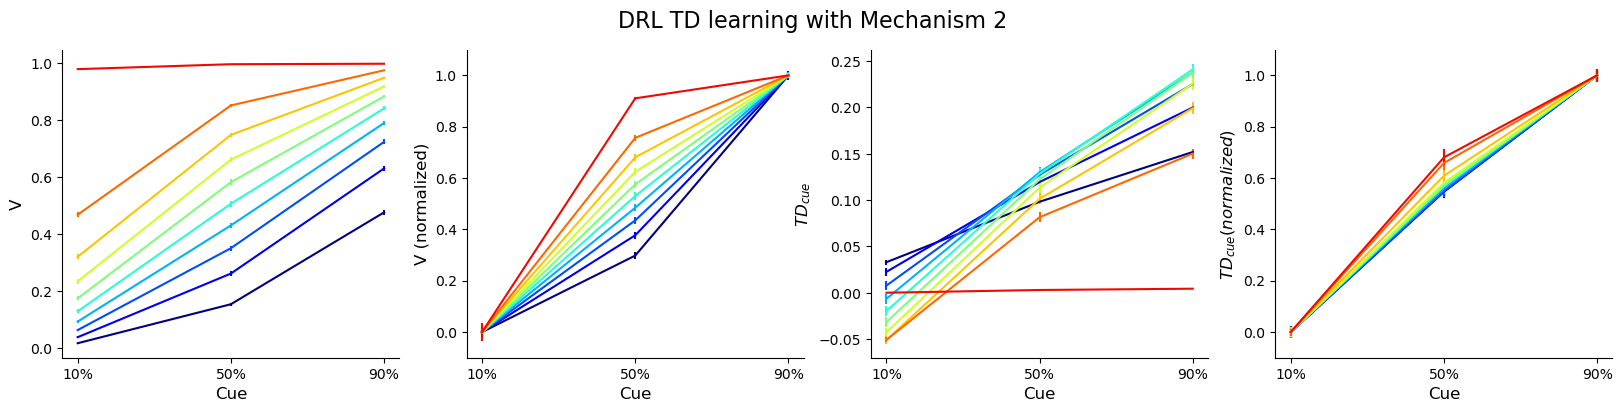

In [21]:
# Plot Supp Fig 5 c-d
idict = save_dics_drl_mech2
taus_i =  taus_rec
ntr_count=-200
id_cue_trtype = [0,1,2]

fig,ax=plt.subplots(1,4,figsize=(20,4))
fig_data_S5cd = FigureWithData(fig)

for (it,tau_i) in enumerate(asym_scaling):
    res = idict[str(tau_i)]['results']
    ag = idict[str(tau_i)]['agent']
    gamma_ = ag['gamma']

    td_trial = np.nanmean(res['deltas_trials_full2'][:,id_cue_trtype,1,ntr_count:],axis=0) #(3x trials)
    td_trial_mu,td_trial_sem = np.nanmean(td_trial,axis=-1), np.nanstd(td_trial,axis=-1)/np.sqrt(np.sum(~np.isnan(td_trial),axis=-1))
    td_trial_n = (td_trial-td_trial_mu[0])/(td_trial_mu[-1]-td_trial_mu[0])
    td_trial_n_mu,td_trial_n_sem = np.nanmean(td_trial_n,axis=-1), np.nanstd(td_trial_n,axis=-1)/np.sqrt(np.sum(~np.isnan(td_trial_n),axis=-1))

    v_trial = np.nanmean(res['distribution_trials_full2'][:,id_cue_trtype,3,ntr_count:] ,axis=0)#(3x trials)
    v_trial_mu,v_trial_sem = np.nanmean(v_trial,axis=-1), np.nanstd(v_trial,axis=-1)/np.sqrt(np.sum(~np.isnan(v_trial),axis=-1))
    v_trial_n = (v_trial-v_trial_mu[0])/(v_trial_mu[-1]-v_trial_mu[0])
    v_trial_n_mu,v_trial_n_sem = np.nanmean(v_trial_n,axis=-1), np.nanstd(v_trial_n,axis=-1)/np.sqrt(np.sum(~np.isnan(v_trial_n),axis=-1))

    ax[0].errorbar(np.arange(len(v_trial)),v_trial_mu,v_trial_sem,color=cm.jet(it/len(taus_i)))
    ax[1].errorbar(np.arange(len(v_trial)),v_trial_n_mu,v_trial_n_sem,color=cm.jet(it/len(taus_i)))
    ax[2].errorbar(np.arange(len(td_trial)),td_trial_mu,td_trial_sem,color=cm.jet(it/len(taus_i)))
    ax[3].errorbar(np.arange(len(td_trial)),td_trial_n_mu,td_trial_n_sem,color=cm.jet(it/len(taus_i)))

    fig_data_S5cd.add_data(
        f"V_tau_{tau_i}",
        np.column_stack((np.arange(len(v_trial_mu)), v_trial_mu, v_trial_sem)),
        ['Cue_Index', 'V_mean', 'V_SEM']
    )
    fig_data_S5cd.add_data(
        f"V_norm_tau_{tau_i}",
        np.column_stack((np.arange(len(v_trial_n_mu)), v_trial_n_mu, v_trial_n_sem)),
        ['Cue_Index', 'V_norm_mean', 'V_norm_SEM']
    )
    fig_data_S5cd.add_data(
        f"TD_tau_{tau_i}",
        np.column_stack((np.arange(len(td_trial_mu)), td_trial_mu, td_trial_sem)),
        ['Cue_Index', 'TD_mean', 'TD_SEM']
    )
    fig_data_S5cd.add_data(
        f"TD_norm_tau_{tau_i}",
        np.column_stack((np.arange(len(td_trial_n_mu)), td_trial_n_mu, td_trial_n_sem)),
        ['Cue_Index', 'TD_norm_mean', 'TD_norm_SEM']
    )


plot_config(ax[0],'Cue',r'V',12,False)
plot_config(ax[1],'Cue',r'V (normalized)' ,12,False)
plot_config(ax[2],'Cue',r'$TD_{cue}$',12,False)
plot_config(ax[3],'Cue',r'$TD_{cue} (normalized)$ ' ,12,False)
[ia.set_xticks(np.arange(len(v_trial))) for ia in ax]
[ia.set_xticklabels(['10%','50%','90%']) for ia in ax]
[ia.set_ylim([-.1,1.1]) for ia in [ax[1],ax[3]]]
plt.suptitle('DRL TD learning with Mechanism 2',fontsize=16)


# --- Save everything
fig_data_S5cd.save(
    base_filename='figure_S5cd_drl_mech2',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)